In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


In [23]:

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Seaborn style
sns.set_theme(style="whitegrid")

In [24]:
df = pd.read_csv('AmazonSalesData.csv')
df.head()


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [25]:
df.shape


(100, 14)

In [26]:
df.columns


Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='object')

In [27]:
df.dtypes

Region             object
Country            object
Item Type          object
Sales Channel      object
Order Priority     object
Order Date         object
Order ID            int64
Ship Date          object
Units Sold          int64
Unit Price        float64
Unit Cost         float64
Total Revenue     float64
Total Cost        float64
Total Profit      float64
dtype: object

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    object 
 1   Country         100 non-null    object 
 2   Item Type       100 non-null    object 
 3   Sales Channel   100 non-null    object 
 4   Order Priority  100 non-null    object 
 5   Order Date      100 non-null    object 
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    object 
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 11.1+ KB


In [29]:
df.describe()

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+02,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02
mean,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
std,2.606153e+08,2794.484562,235.592241,188.208181,1.460029e+06,1.083938e+06,4.385379e+05
min,1.146066e+08,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03
25%,3.389225e+08,2836.250000,81.730000,35.840000,2.687212e+05,1.688680e+05,1.214436e+05
50%,5.577086e+08,5382.500000,179.880000,107.275000,7.523144e+05,3.635664e+05,2.907680e+05
75%,7.907551e+08,7369.000000,437.200000,263.330000,2.212045e+06,1.613870e+06,6.358288e+05
max,9.940222e+08,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.719922e+06


In [30]:
df.describe(include='object')

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Ship Date
count,100,100,100,100,100,100,100
unique,7,76,12,2,4,100,99
top,Sub-Saharan Africa,The Gambia,Cosmetics,Offline,H,5/28/2010,11/17/2010
freq,36,4,13,50,30,1,2


In [31]:
df['Region'].value_counts()


Region
Sub-Saharan Africa                   36
Europe                               22
Australia and Oceania                11
Asia                                 11
Middle East and North Africa         10
Central America and the Caribbean     7
North America                         3
Name: count, dtype: int64

In [32]:
df['Item Type'].value_counts()


Item Type
Cosmetics          13
Clothes            13
Office Supplies    12
Fruits             10
Personal Care      10
Household           9
Beverages           8
Cereal              7
Baby Food           7
Vegetables          6
Snacks              3
Meat                2
Name: count, dtype: int64

In [33]:
df['Sales Channel'].value_counts()


Sales Channel
Offline    50
Online     50
Name: count, dtype: int64

In [34]:
df['Order Priority'].value_counts()

Order Priority
H    30
L    27
C    22
M    21
Name: count, dtype: int64

In [35]:
df.isnull().sum()

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [36]:
missing_percentage = df.isnull().mean() * 100

missing_percentage.sort_values(ascending=False)

Region            0.0
Country           0.0
Item Type         0.0
Sales Channel     0.0
Order Priority    0.0
Order Date        0.0
Order ID          0.0
Ship Date         0.0
Units Sold        0.0
Unit Price        0.0
Unit Cost         0.0
Total Revenue     0.0
Total Cost        0.0
Total Profit      0.0
dtype: float64

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df['Order ID'].duplicated().sum()

np.int64(0)

In [39]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [40]:
df.dtypes

Region                    object
Country                   object
Item Type                 object
Sales Channel             object
Order Priority            object
Order Date        datetime64[ns]
Order ID                   int64
Ship Date         datetime64[ns]
Units Sold                 int64
Unit Price               float64
Unit Cost                float64
Total Revenue            float64
Total Cost               float64
Total Profit             float64
dtype: object

In [41]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter

In [44]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [46]:
df.head()


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Year,Month,Month Name,Quarter,Shipping Days
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,2010-05-28,669165933,2010-06-27,9925,255.28,159.42,2533654.00,1582243.50,951410.50,2010,5,May,2,30
1,Central America and the Caribbean,Grenada,Cereal,Online,C,2012-08-22,963881480,2012-09-15,2804,205.70,117.11,576782.80,328376.44,248406.36,2012,8,August,3,24
2,Europe,Russia,Office Supplies,Offline,L,2014-05-02,341417157,2014-05-08,1779,651.21,524.96,1158502.59,933903.84,224598.75,2014,5,May,2,6
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,2014-06-20,514321792,2014-07-05,8102,9.33,6.92,75591.66,56065.84,19525.82,2014,6,June,2,15
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2013-02-01,115456712,2013-02-06,5062,651.21,524.96,3296425.02,2657347.52,639077.50,2013,2,February,1,5


In [49]:
df[['Order Date', 'Ship Date', 'Shipping Days']].head(10)

,Order Date,Ship Date,Shipping Days
0,2010-05-28,2010-06-27,30
1,2012-08-22,2012-09-15,24
2,2014-05-02,2014-05-08,6
3,2014-06-20,2014-07-05,15
4,2013-02-01,2013-02-06,5
5,2015-02-04,2015-02-21,17
6,2011-04-23,2011-04-27,4
7,2012-07-17,2012-07-27,10
8,2015-07-14,2015-08-25,42
9,2014-04-18,2014-05-30,42


In [54]:
df['Profit Margin %'] = (
    df['Total Profit'] / df['Total Revenue']
) * 100
df['Profit Margin %'] 

0     37.550924
1     43.067574
2     19.386987
3     25.830654
4     19.386987
5     37.550924
6     24.799856
7     40.977541
8     30.661936
9     43.067574
10    40.977541
11    67.203514
12    67.203514
13    24.799856
14    30.661936
15    67.203514
16    39.768984
17    33.003161
18    24.799856
19    13.558036
20    37.550924
21    37.550924
22    36.138419
23    25.830654
24    30.661936
25    39.768984
26    25.830654
27    25.830654
28    33.003161
29    24.799856
30    39.768984
31    30.661936
32    19.386987
33    24.799856
34    36.138419
35    30.661936
36    25.830654
37    13.558036
38    19.386987
39    19.386987
40    30.661936
41    39.768984
42    43.067574
43    40.977541
44    67.203514
45    43.067574
46    39.768984
47    30.661936
48    67.203514
49    19.386987
50    67.203514
51    25.830654
52    43.067574
53    19.386987
54    25.830654
55    67.203514
56    67.203514
57    39.768984
58    24.799856
59    39.768984
60    43.067574
61    37.550924
62    19

In [62]:

df['Calculated Revenue'] = (
    df['Units Sold'] * df['Unit Price']
)

df['Calculated Revenue']

0     2533654.00
1      576782.80
2     1158502.59
3       75591.66
4     3296425.02
5      759202.72
6     2798046.49
7     1245112.92
8      496101.10
9     1356180.10
10      19103.44
11     455479.04
12     902980.64
13    5997054.98
14     400558.73
15     182825.44
16    3039414.40
17     257653.50
18    2559474.10
19    2492526.12
20    1901836.00
21     324971.44
22     339490.50
23      20404.71
24     414371.10
25     793518.00
26      50363.34
27      54319.26
28     243133.80
29    1583799.90
30    3786589.20
31     173676.25
32    1904138.04
33    5513227.50
34    1117953.66
35     523807.57
36      35304.72
37    2011149.63
38    4368316.68
39    2596374.27
40     246415.95
41    3162704.80
42     435466.90
43      26344.26
44     648030.40
45     197883.40
46    3876652.40
47      22312.29
48     856973.76
49     824431.86
50     247956.32
51      89623.98
52     835759.10
53    2251232.97
54      71253.21
55     380512.96
56    1082418.40
57    1244708.40
58     188452.

In [68]:
df['Revenue Difference'] = (
    df['Total Revenue'] - df['Calculated Revenue']
)
df['Revenue Difference'].abs().max()
df['Revenue Difference']

0     0.000000e+00
1     1.164153e-10
2     0.000000e+00
3     0.000000e+00
4     0.000000e+00
5     0.000000e+00
6     4.656613e-10
7     0.000000e+00
8    -5.820766e-11
9     2.328306e-10
10    0.000000e+00
11    0.000000e+00
12    0.000000e+00
13    9.313226e-10
14   -5.820766e-11
15    0.000000e+00
16    0.000000e+00
17   -2.910383e-11
18    0.000000e+00
19    0.000000e+00
20    0.000000e+00
21    0.000000e+00
22    0.000000e+00
23    0.000000e+00
24   -5.820766e-11
25    0.000000e+00
26   -7.275958e-12
27    0.000000e+00
28   -2.910383e-11
29    0.000000e+00
30    4.656613e-10
31    0.000000e+00
32    0.000000e+00
33    0.000000e+00
34   -2.328306e-10
35    0.000000e+00
36    0.000000e+00
37    0.000000e+00
38   -9.313226e-10
39    0.000000e+00
40    0.000000e+00
41    0.000000e+00
42    5.820766e-11
43   -3.637979e-12
44    0.000000e+00
45    0.000000e+00
46    0.000000e+00
47    0.000000e+00
48    0.000000e+00
49   -1.164153e-10
50    0.000000e+00
51    0.000000e+00
52    0.0000

In [69]:
df['Calculated Cost'] = (
    df['Units Sold'] * df['Unit Cost']
)

df['Cost Difference'] = (
    df['Total Cost'] - df['Calculated Cost']
)

df['Cost Difference'].abs().max()

np.float64(9.313225746154785e-10)

In [71]:
df['Calculated Profit'] = (
    df['Total Revenue'] - df['Total Cost']
)

df['Profit Difference'] = (
    df['Total Profit'] - df['Calculated Profit']
)

df['Profit Difference'].abs().max()

np.float64(4.656612873077393e-10)

In [73]:
numeric_columns = [
    'Units Sold',
    'Unit Price',
    'Unit Cost',
    'Total Revenue',
    'Total Cost',
    'Total Profit'
]

(df[numeric_columns] < 0).sum()

Units Sold       0
Unit Price       0
Unit Cost        0
Total Revenue    0
Total Cost       0
Total Profit     0
dtype: int64

In [75]:
for column in ['Region', 'Country', 'Item Type',
               'Sales Channel', 'Order Priority']:
    
    print("\n", column)
    print(df[column].unique())


 Region
['Australia and Oceania' 'Central America and the Caribbean' 'Europe'
 'Sub-Saharan Africa' 'Asia' 'Middle East and North Africa'
 'North America']

 Country
['Tuvalu' 'Grenada' 'Russia' 'Sao Tome and Principe' 'Rwanda'
 'Solomon Islands' 'Angola' 'Burkina Faso' 'Republic of the Congo'
 'Senegal' 'Kyrgyzstan' 'Cape Verde' 'Bangladesh' 'Honduras' 'Mongolia'
 'Bulgaria' 'Sri Lanka' 'Cameroon' 'Turkmenistan' 'East Timor' 'Norway'
 'Portugal' 'New Zealand' 'Moldova ' 'France' 'Kiribati' 'Mali'
 'The Gambia' 'Switzerland' 'South Sudan' 'Australia' 'Myanmar' 'Djibouti'
 'Costa Rica' 'Syria' 'Brunei' 'Niger' 'Azerbaijan' 'Slovakia' 'Comoros'
 'Iceland' 'Macedonia' 'Mauritania' 'Albania' 'Lesotho' 'Saudi Arabia'
 'Sierra Leone' "Cote d'Ivoire" 'Fiji' 'Austria' 'United Kingdom'
 'San Marino' 'Libya' 'Haiti' 'Gabon' 'Belize' 'Lithuania' 'Madagascar'
 'Democratic Republic of the Congo' 'Pakistan' 'Mexico'
 'Federated States of Micronesia' 'Laos' 'Monaco' 'Samoa ' 'Spain'
 'Lebanon' 'Iran

In [81]:
text_columns = [
    'Region',
    'Country',
    'Item Type',
    'Sales Channel',
    'Order Priority'
]

for col in text_columns:
    df[col] = df[col].str.strip()

In [82]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit,Year,Month,Month Name,Quarter,Shipping Days,Profit Margin %,Calculated Revenue,Revenue Difference,Calculated Cost,Cost Difference,Calculated Profit,Profit Difference
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,2010-05-28,669165933,2010-06-27,9925,255.28,159.42,2533654.00,1582243.50,951410.50,2010,5,May,2,30,37.550924,2533654.00,0.000000e+00,1582243.50,2.328306e-10,951410.50,0.000000e+00
1,Central America and the Caribbean,Grenada,Cereal,Online,C,2012-08-22,963881480,2012-09-15,2804,205.70,117.11,576782.80,328376.44,248406.36,2012,8,August,3,24,43.067574,576782.80,1.164153e-10,328376.44,0.000000e+00,248406.36,-5.820766e-11
2,Europe,Russia,Office Supplies,Offline,L,2014-05-02,341417157,2014-05-08,1779,651.21,524.96,1158502.59,933903.84,224598.75,2014,5,May,2,6,19.386987,1158502.59,0.000000e+00,933903.84,-1.164153e-10,224598.75,-1.164153e-10
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,2014-06-20,514321792,2014-07-05,8102,9.33,6.92,75591.66,56065.84,19525.82,2014,6,June,2,15,25.830654,75591.66,0.000000e+00,56065.84,0.000000e+00,19525.82,-7.275958e-12
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2013-02-01,115456712,2013-02-06,5062,651.21,524.96,3296425.02,2657347.52,639077.50,2013,2,February,1,5,19.386987,3296425.02,0.000000e+00,2657347.52,0.000000e+00,639077.50,0.000000e+00


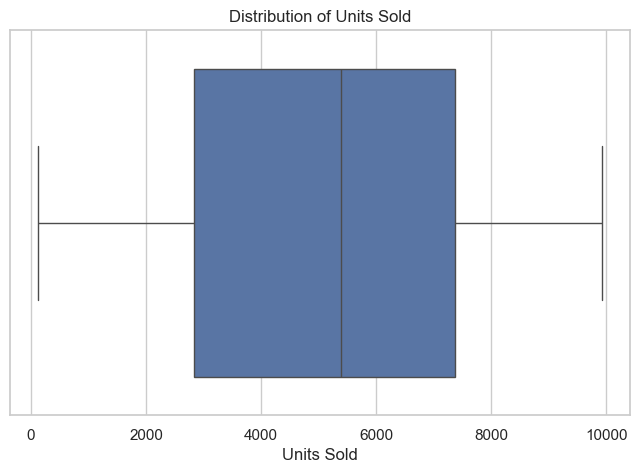

In [79]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df['Units Sold'])

plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')

plt.show()

In [83]:
total_revenue = df['Total Revenue'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $137,348,768.31


In [85]:
total_profit = df['Total Profit'].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $44,168,198.40


In [87]:
profit_margin = (
    total_profit / total_revenue
) * 100

print(f"Overall Profit Margin: {profit_margin:.2f}%")

Overall Profit Margin: 32.16%


In [89]:
region_profit = (
    df.groupby('Region')['Total Profit']
      .sum()
      .sort_values(ascending=False)
)

region_profit

Region
Sub-Saharan Africa                   12183211.40
Europe                               11082938.63
Asia                                  6113845.87
Middle East and North Africa          5761191.86
Australia and Oceania                 4722160.03
Central America and the Caribbean     2846907.85
North America                         1457942.76
Name: Total Profit, dtype: float64

In [91]:
region_analysis = (
    df.groupby('Region')
      .agg(
          Revenue=('Total Revenue', 'sum'),
          Cost=('Total Cost', 'sum'),
          Profit=('Total Profit', 'sum'),
          Units=('Units Sold', 'sum'),
          Orders=('Order ID', 'count')
      )
      .sort_values('Profit', ascending=False)
)

region_analysis

,Revenue,Cost,Profit,Units,Orders
Region,,,,,
Sub-Saharan Africa,39672031.43,27488820.03,12183211.40,182870,36
Europe,33368932.11,22285993.48,11082938.63,98117,22
Asia,21347091.02,15233245.15,6113845.87,59967,11
Middle East and North Africa,14052706.58,8291514.72,5761191.86,48678,10
Australia and Oceania,14094265.13,9372105.10,4722160.03,68325,11
Central America and the Caribbean,9170385.49,6323477.64,2846907.85,35771,7
North America,5643356.55,4185413.79,1457942.76,19143,3


In [93]:
product_analysis = (
    df.groupby('Item Type')
      .agg(
          Revenue=('Total Revenue', 'sum'),
          Cost=('Total Cost', 'sum'),
          Profit=('Total Profit', 'sum'),
          Units=('Units Sold', 'sum'),
          Orders=('Order ID', 'count')
      )
      .sort_values('Profit', ascending=False)
)

product_analysis

,Revenue,Cost,Profit,Units,Orders
Item Type,,,,,
Cosmetics,36601509.60,22045460.94,14556048.66,83718,13
Household,29889712.29,22477106.58,7412605.71,44727,9
Office Supplies,30585380.07,24655796.32,5929583.75,46967,12
Clothes,7787292.80,2553958.40,5233334.40,71260,13
Baby Food,10350327.60,6463683.90,3886643.70,40545,7
Cereal,5322898.90,3030455.47,2292443.43,25877,7
Vegetables,3089057.06,1823237.43,1265819.63,20051,6
Personal Care,3980904.84,2760282.36,1220622.48,48708,10
Beverages,2690794.60,1802747.32,888047.28,56708,8


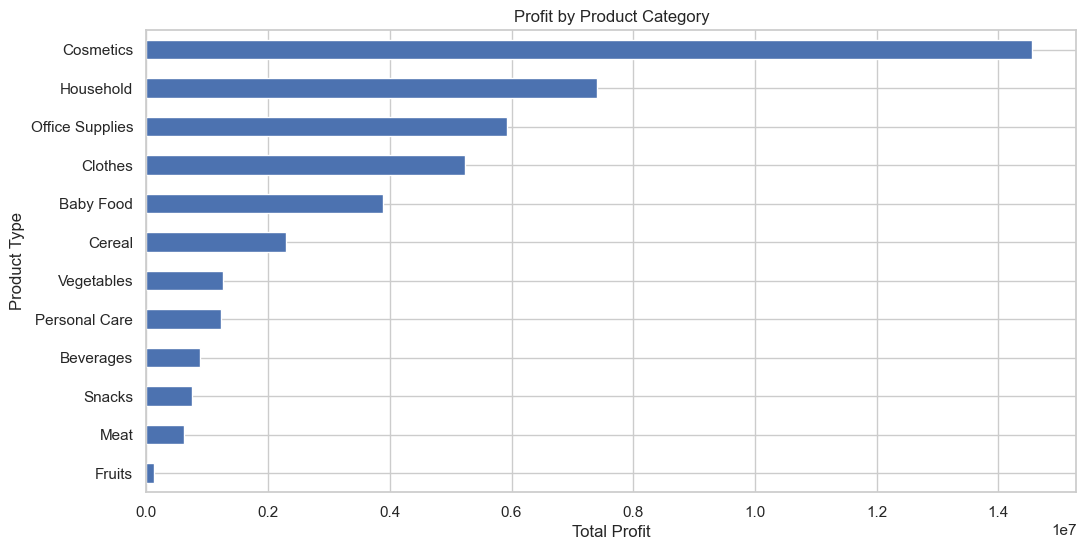

In [95]:
plt.figure(figsize=(12, 6))

product_analysis['Profit'].sort_values().plot(
    kind='barh'
)

plt.title('Profit by Product Category')
plt.xlabel('Total Profit')
plt.ylabel('Product Type')

plt.show()

In [97]:
channel_analysis = (
    df.groupby('Sales Channel')
      .agg(
          Revenue=('Total Revenue', 'sum'),
          Cost=('Total Cost', 'sum'),
          Profit=('Total Profit', 'sum'),
          Orders=('Order ID', 'count')
      )
)

channel_analysis

,Revenue,Cost,Profit,Orders
Sales Channel,,,,
Offline,79094809.20,54174082.53,24920726.67,50
Online,58253959.11,39006487.38,19247471.73,50


In [99]:
yearly_sales = (
    df.groupby('Year')
      .agg(
          Revenue=('Total Revenue', 'sum'),
          Profit=('Total Profit', 'sum'),
          Units=('Units Sold', 'sum')
      )
)

yearly_sales

,Revenue,Profit,Units
Year,,,
2010,19186024.92,6629567.43,61571
2011,11129166.07,2741008.23,54768
2012,31898644.52,9213010.12,97967
2013,20330448.66,6715420.04,64663
2014,16630214.43,5879461.68,92040
2015,12427982.86,3996539.44,49480
2016,12372867.22,4903838.01,43156
2017,13373419.63,4089353.45,49226


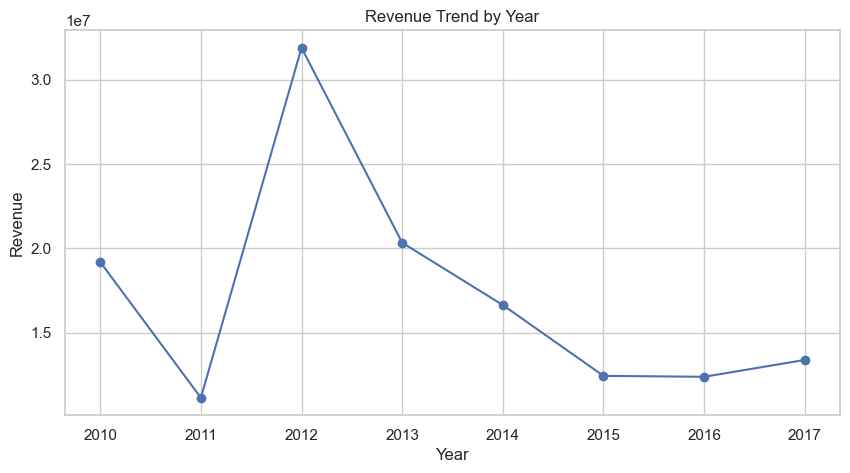

In [101]:
plt.figure(figsize=(10, 5))

plt.plot(
    yearly_sales.index,
    yearly_sales['Revenue'],
    marker='o'
)

plt.title('Revenue Trend by Year')
plt.xlabel('Year')
plt.ylabel('Revenue')

plt.show()

In [103]:
monthly_sales = (
    df.groupby('Month')
      .agg(
          Revenue=('Total Revenue', 'sum'),
          Profit=('Total Profit', 'sum')
    )
)

monthly_sales

,Revenue,Profit
Month,,
1,10482467.12,2816857.02
2,24740517.77,7072050.51
3,2274823.87,928351.06
4,16187186.33,4760208.35
5,13215739.99,4582692.30
6,5230325.77,2185379.43
7,15669518.50,5578463.06
8,1128164.91,579276.67
9,5314762.56,2344166.03


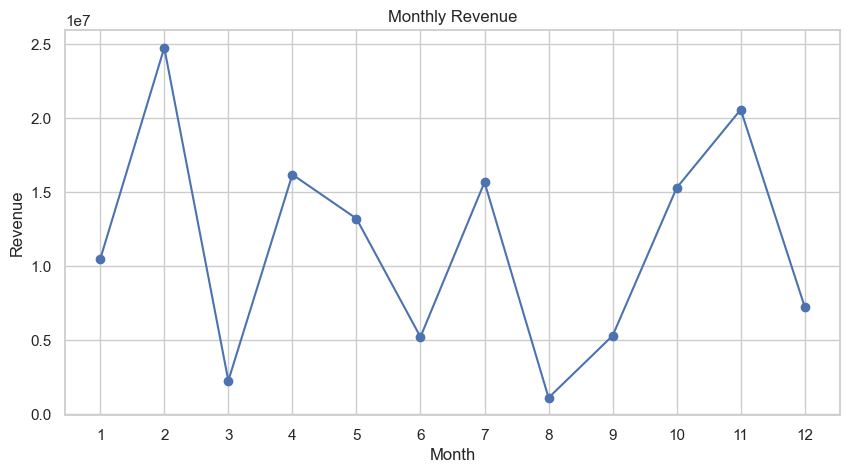

In [108]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales['Revenue'],
    marker='o'
)

plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.xticks(range(1, 13))

plt.show()